# تسک هفتگی شماره ۱

## Data Understanding بر اساس فرآیند CRISP-DM

### سناریوی کسب‌وکار

شما به عنوان تحلیلگر داده در یک مرکز درمانی قلب و عروق استخدام شده‌اید.

مدیریت مرکز قصد دارد یک سیستم هوشمند غربالگری اولیه برای تشخیص ریسک بیماری قلبی طراحی کند تا بیماران پرخطر قبل از انجام آزمایش‌های گران‌قیمت شناسایی شوند.

قبل از هرگونه مدل‌سازی، تیم داده باید شناخت کاملی از داده‌ها به دست آورد:

- چه نوع بیمارانی در دیتاست حضور دارند؟
- چه ویژگی‌هایی احتمالاً با بیماری قلبی مرتبط هستند؟
- توزیع بیماران چگونه است؟
- آیا داده متعادل است؟
- آیا الگوهای خاصی در گروه‌های مختلف بیماران وجود دارد؟
- آیا کیفیت داده برای مدل‌سازی مناسب است؟

مدیریت از شما خواسته است تنها با استفاده از مرحله Data Understanding گزارش اولیه‌ای از وضعیت داده‌ها تهیه کنید.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## دیتاست

Heart Disease UCI

### لینک گیت‌هاب:

url = https://github.com/trojrobert/Classification-of-heart-disease-uci-data-/blob/master/heart.csv?utm_source=chatgpt.com

### اطلاعات کلی دیتاست:

حدود 300 رکورد
14 ویژگی
هدف: تشخیص وجود یا عدم وجود بیماری قلبی

### ویژگی هدف:

target

- 0 → بدون بیماری قلبی

- 1 → دارای بیماری قلبی

این دیتاست یکی از مشهورترین دیتاست‌های حوزه سلامت است و بارها در تحقیقات پزشکی و داده‌کاوی استفاده شده است.

---



In [2]:
df = pd.read_csv("heart.csv")

# خروجی مورد انتظار

دانشجو باید یک Notebook تحویل دهد که شامل:

کد هر سوال
خروجی کد
تحلیل شخصی از خروجی

برای هر سوال حداقل ۳ تا ۵ خط تحلیل نوشته شود.

صرفاً گذاشتن نمودار یا جدول بدون تحلیل نمره ندارد.

---

# قوانین

- استفاده از Scikit-Learn ممنوع

- انجام Data Cleaning ممنوع

- حذف داده ممنوع

- Feature Engineering ممنوع

### فقط از پکیج های زیر استفاده شود:

1. NumPy

2. Pandas

3. Matplotlib

4. Seaborn

---

# بخش اول: شناخت اولیه دیتاست

### سوال 1
چند سطر و چند ستون در دیتاست وجود دارد؟

ابزار پیشنهادی:

- shape

In [3]:
df.shape


(303, 14)

### Analysis of Question 1:

۳۰۳ رکورد
۱۴ ستون


---

### سوال 2

نام تمام ستون‌ها چیست؟

ابزار پیشنهادی: columns

In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

### Analysis of Question 2:

age سن

sex جنسیت

cp نوع درد قفسه سینه 

trestbps فشار خون استراحت

chol کلسترول

fbs  قند خون ناشتا

restecg نوار قلب

thalach حداکثر ضربان قلب

exang آنژین ناشی از ورزش

oldpeak stافت موج 

slope شیب قطعه اس تی در ورزش

ca تعداد عروق اصلی

thal تالاسمی

target متغییر هدف


---

### سوال 3

نوع داده هر ستون چیست؟

ابزار پیشنهادی: dtypes , info()

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### Analysis of Question 3

    age       int64  
    sex       int64  
    cp        int64  
    trestbps  int64  
    chol      int64  
    fbs       int64  
    restecg   int64  
    thalach   int64  
    exang     int64  
    oldpeak   float64
    slope     int64  
    ca        int64  
    thal      int64  
    target    int64 

---

### سوال 4

برای هر ستون تعیین کنید:

- عددی
- دسته‌ای
- دودویی

In [6]:
for index in df.columns:
    number_unique = df[index].nunique()
    types = None
    if number_unique == 2:
        types = "boolian"
    elif 6 > number_unique > 2:
        types = "categorical"
    else:
        types = "numerical"
    print(f"{index}: {number_unique} -> {types}")


age: 41 -> numerical
sex: 2 -> boolian
cp: 4 -> categorical
trestbps: 49 -> numerical
chol: 152 -> numerical
fbs: 2 -> boolian
restecg: 3 -> categorical
thalach: 91 -> numerical
exang: 2 -> boolian
oldpeak: 40 -> numerical
slope: 3 -> categorical
ca: 5 -> categorical
thal: 4 -> categorical
target: 2 -> boolian


### Analysis of Question 4

age: عددی

sex: دسته ای

cp: دسته ای

trestbps: عددی

chol: عددی

fbs: دودویی

restecg: دسته ای 

thalach: عددی

exang: دودویی

oldpeak: عددی

slope: دسته ای

ca: دسته ای

thal: دسته ای

 target:  دودویی



---

### سوال 5

از دید کسب‌وکار، هر ستون چه مفهومی دارد؟

(جدول توضیحات تهیه شود.)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### Analysis of Question 5


ویژگی|ترجمه|نوع
|---|---|---|
|age | سن|عددی
|sex |جنسیت|دسته ای
|cp |نوع درد قفسه سینه |دسته ای
|trestbps |فشار خون استراحت|عددی
|chol |کلسترول|عددی
|fbs | قند خون ناشتا|دودویی
|restecg |نوار قلب|دسته ای
|thalach |حداکثر ضربان قلب|عددی
|exang |آنژین ناشی از ورزش|دودویی
|oldpeak |stافت موج |عددی
|slope |شیب قطعه اس تی در ورزش|دسته ای
|ca |تعداد عروق اصلی|دودویی
|thal |تالاسمی|دسته ای
|target |متغییر هدف |دودویی 


---

# بخش دوم: کیفیت داده

### سوال 6

در هر ستون چند مقدار Null وجود دارد؟

In [8]:
for index in df.columns:
    print(f"{index} -> {df[index].isna().sum()}")

age -> 0
sex -> 0
cp -> 0
trestbps -> 0
chol -> 0
fbs -> 0
restecg -> 0
thalach -> 0
exang -> 0
oldpeak -> 0
slope -> 0
ca -> 0
thal -> 0
target -> 0


### Analysis of Question 6

هیچ مقدار خالی وجود ندارد


---

### سوال 7

درصد داده‌های گمشده هر ستون چقدر است؟

In [9]:
for index in df.columns:
    missing_value = (df[index] == "").sum() + df[index].isna().sum()
    print(f"{index} -> {missing_value} null")

age -> 0 null
sex -> 0 null
cp -> 0 null
trestbps -> 0 null
chol -> 0 null
fbs -> 0 null
restecg -> 0 null
thalach -> 0 null
exang -> 0 null
oldpeak -> 0 null
slope -> 0 null
ca -> 0 null
thal -> 0 null
target -> 0 null


### Analysis of Question 7

با محاسبه درصد داده‌های گمشده مشاهده می‌شود که در تمام ستون‌ها مقدار میسینگ ولیو برابر صفر است
از آنجا که دیتاست ۳۰۳ رکورد دارد و هیچ مقداری نال یا خالی ثبت نشده است، درصد داده‌های گمشده برای همه ستون‌ها برابر با ۰٪ است
این موضوع نشان می‌دهد که برای مرحله پیش‌پردازش نیازی به حذف رکوردها یا جایگزینی مقادیر گمشده وجود ندارد
کیفیت داده از نظر کامل بودن مناسب است و می‌توان تحلیل را مستقیماً روی داده‌ها انجام داد

___

### سوال 8

آیا رکورد تکراری وجود دارد؟

In [10]:
df.loc[df.duplicated(keep = False)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


### Analysis of Question 8

ردیف ۱۶۴ تکرار ردیف ۱۶۳ هست


---

### سوال 9

اگر رکورد تکراری وجود دارد:

- چند عدد است؟
- چند درصد کل داده است؟

In [11]:
duplicate = df.duplicated().sum()
duplicate_percent = (duplicate / len(df) *100).round(2)
print(f"{duplicate_percent}%")

0.33%


### Analysis of Question 9

در دیتاست تنها ۱ رکورد تکراری وجود دارد
 درصد داده‌های تکراری:
۱/۳۰۳ * ۱۰۰ = ۰.۳۳٪
 کمتر از یک درصد داده‌ها تکراری هستن
در پروژه‌های داده‌کاوی بهتره رکورد تکراری حذف شوند تا از ایجاد سوگیری در تحلیل‌ها جلوگیری بشود


---

# بخش سوم: شناخت متغیر هدف

### سوال 10

توزیع کلاس‌های target چگونه است؟

ابزار:
- value_counts
- countplot
- pie chart

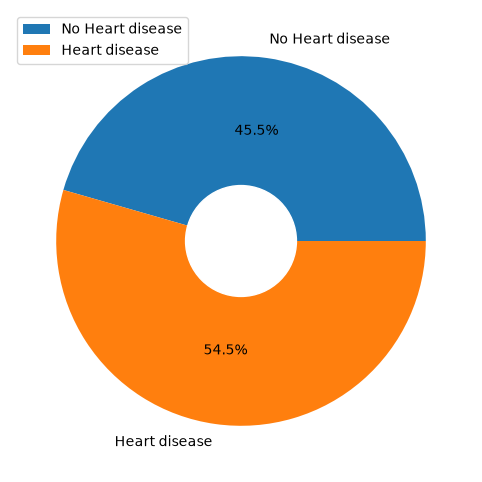

/tmp/ipykernel_6406/3247587501.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["woman","men"])


[Text(0, 0, 'woman'), Text(1, 0, 'men')]

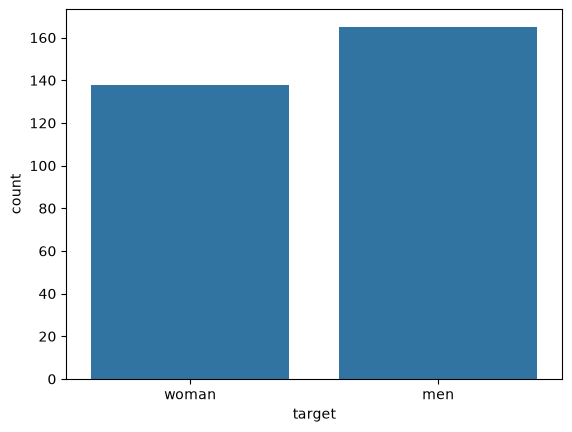

In [12]:
target = df["target"].value_counts().sort_index()
label = []

for index in target.index:
    if index == 0:
        index = "No Heart disease"
        label.append(index)
    else:
        index = "Heart disease"
        label.append(index)
plt.figure(figsize =(12,6))   
plt.pie(target,labels = label,autopct='%1.1f%%' , startangle = 0)
plt.legend(loc = "upper left")
circle = plt.Circle((0,0),0.3,color="white")
plt.gca().add_artist(circle)
plt.show()
ax = sns.countplot(x="target",data = df)
ax.set_xticklabels(["woman","men"])



### Analysis of Question 10

 ۴۵.۵٪ بیمار هستن 
 ۵۴.۵٪ سالم هستن
 تعداد افراد مبتلا به بیماری قلبی کمی بیشتر از افراد سالمه
اختلاف بین دو کلاس زیاد نیست و هر دو کلاس تعداد مناسبی نمونه دارن
این توزیع برای آموزش مدل‌های ماشین لرنینگ مناسبه و احتمال بروز مشکل شدید عدم توازن کلاس‌ها کم هست


---

### سوال 11

آیا دیتاست متعادل است؟

با عدد و نمودار توضیح دهید.

In [13]:
target = df["target"].value_counts().sort_index()
ratio = target.min() / target.max().round(2)

if ratio > 0.8:
    b = ("balance")
elif 0.8 > ratio > 0.4:
    b = ("middle")
else:
    b = ("unbalance")    
print(f"{ratio} -> {b}")




0.8363636363636363 -> balance


### Analysis of Question 11

برای متعادل بودن باید ستون تارگت رو بررسی کنیم و اگر بالای ۰.۸ باشه متعادل است


---

# بخش چهارم: تحلیل ویژگی‌های عددی

ویژگی‌های عددی را استخراج کنید.

### سوال 12

برای تمام ویژگی‌های عددی آمار توصیفی کامل استخراج کنید.

ابزار:
- describe()

In [37]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if number_unique > 6:
        col.append(index)
df[col].describe()

,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.623762,246.264026,149.646865,1.039604
std,9.082101,17.538143,51.830751,22.905161,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,47.500000,120.000000,211.000000,133.500000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000
75%,61.000000,140.000000,274.500000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


### Analysis of Question 12

آمار توصیفی ویژگی‌های عددی : میانگین، میانه، انحراف معیار، حداقل، حداکثر و چارک‌ها محاسبه شد
برای تشخیص پراکندگی و دامنه تغییرات هر ویژگی
 برخی ویژگی‌ها مانند کلسترول و فشار خون در استراحت دارای دامنه تغییرات نسبتاً بزرگی هستن که ممکنه نشان‌ دهنده وجود داده‌های پرت باشد
همچنین ویژگی‌های سن و حداکثر ضربان قلب پراکندگی منطقی دارند


---

### سوال 13

برای هر ویژگی عددی:

- میانگین
- میانه
- مد

را محاسبه کنید.

In [38]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if number_unique > 6:
        col.append(index)
dict = {}
for index in df[col]:
    dict[index] = {
    "median" : df[index].median(),
    "mean" :df[index].mean(),
    "mode" : df[index].mode()[0]
    }
df2 = pd.DataFrame(dict).T
df2

,median,mean,mode
age,55.0,54.366337,58.0
trestbps,130.0,131.623762,120.0
chol,240.0,246.264026,197.0
thalach,153.0,149.646865,162.0
oldpeak,0.8,1.039604,0.0


### Analysis of Question 13

میانگین، میانه و مد برای تمام ویژگی‌های عددی محاسبه شد
اگر میانگین و میانه به یکدیگر نزدیک باشند، توزیع داده نسبتاً متقارن است
در برخی ویژگی‌ها مانند کلسترول و افت موج اختلاف میانگین و میانه مشاهده می‌شود که می‌تواند نشانه وجود چولگی یا داده‌های پرت باشد.
مقایسه این سه شاخص کمک می‌کند شکل کلی توزیع داده‌ها بهتر درک شود


---

### سوال 14

برای هر ویژگی عددی:

- واریانس
- انحراف معیار

را محاسبه کنید.

In [39]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if number_unique > 6:
        col.append(index)
dict = {}
for index in df[col]:
    dict[index] = {
    "std" : df[index].std(),
    "var" :df[index].var(),
    }
df2 = pd.DataFrame(dict).T
df2

,std,var
age,9.082101,82.484558
trestbps,17.538143,307.586453
chol,51.830751,2686.426748
thalach,22.905161,524.646406
oldpeak,1.161075,1.348095


### Analysis of Question 14

واریانس و انحراف معیار میزان پراکندگی داده‌ها را نشان می‌دهند
ویژگی‌هایی مانند کلسترول و حداکثر ضربان قلب دارای انحراف معیار بالاتری هستند که بیانگر تنوع بیشتر مقادیر در بین افراد است
در مقابل برخی ویژگی‌ها مانند افت موج پراکندگی کمتری دارند
ویژگی‌هایی با پراکندگی بالا معمولاً تأثیر بیشتری بر مدل‌ها دارند و ممکن است نیازمند نرمال‌سازی باشند


---

### سوال 15

برای هر ویژگی عددی هیستوگرام رسم کنید.

تحلیل:

- شکل توزیع
- چولگی احتمالی

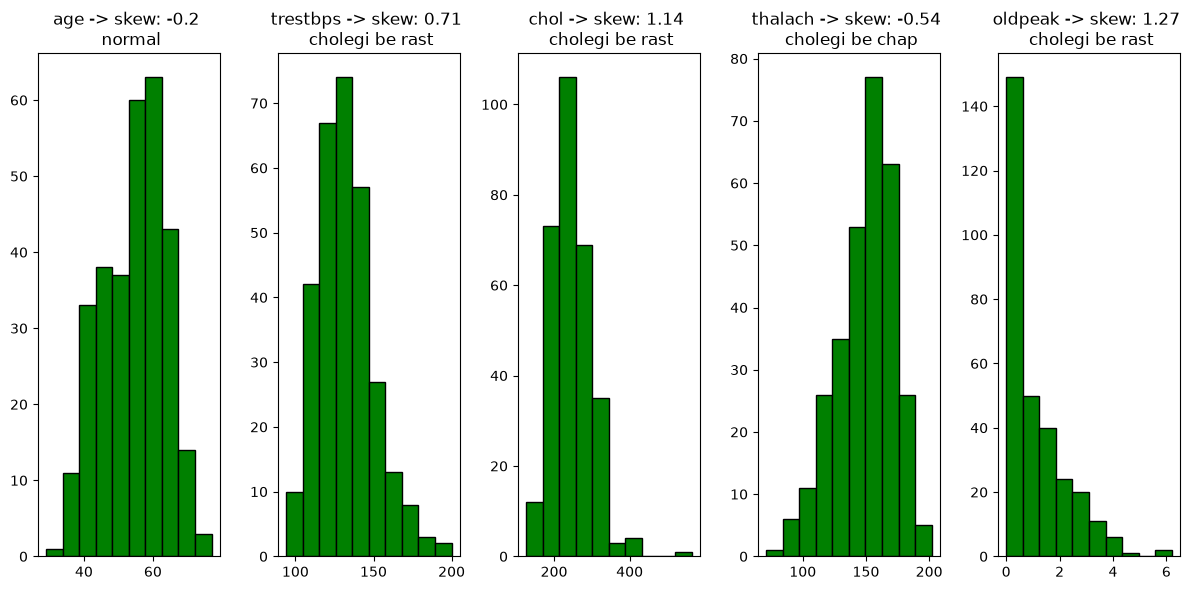

In [50]:
col_list = []
for index in df.columns:
    number_unique = df[index].nunique()
    if number_unique > 6:
        col_list.append(index)
fig , ax = plt.subplots(nrows = 1 , ncols = len(col_list) , figsize=(12,6))
for index , col in enumerate(col_list):
    ax[index].hist(df[col],color="green",edgecolor="black")
    cholegi = df[col].skew().round(2)
    if cholegi > 0.5:
        a ="cholegi be rast"
    elif cholegi < -0.5:
        a = "cholegi be chap"
    else:
        a = "normal"
    ax[index].set_title(f"{df[col].name} -> skew: {cholegi} \n {a}")
plt.tight_layout()
plt.show()



### Analysis of Question 15

بررسی هیستوگرام ویژگی‌های عددی نشان می‌دهد که اکثر متغیرها توزیع نرمال کامل ندارند
وجود چولگی در برخی ویژگی‌ها می‌تواند روی عملکرد بعضی مدل‌های آماری اثر بگذارد و در صورت نیاز می‌توان از تبدیل‌های آماری استفاده کرد


---

### سوال 16

برای تمام ویژگی‌های عددی Boxplot رسم کنید.

تحلیل:

- وجود یا عدم وجود Outlier

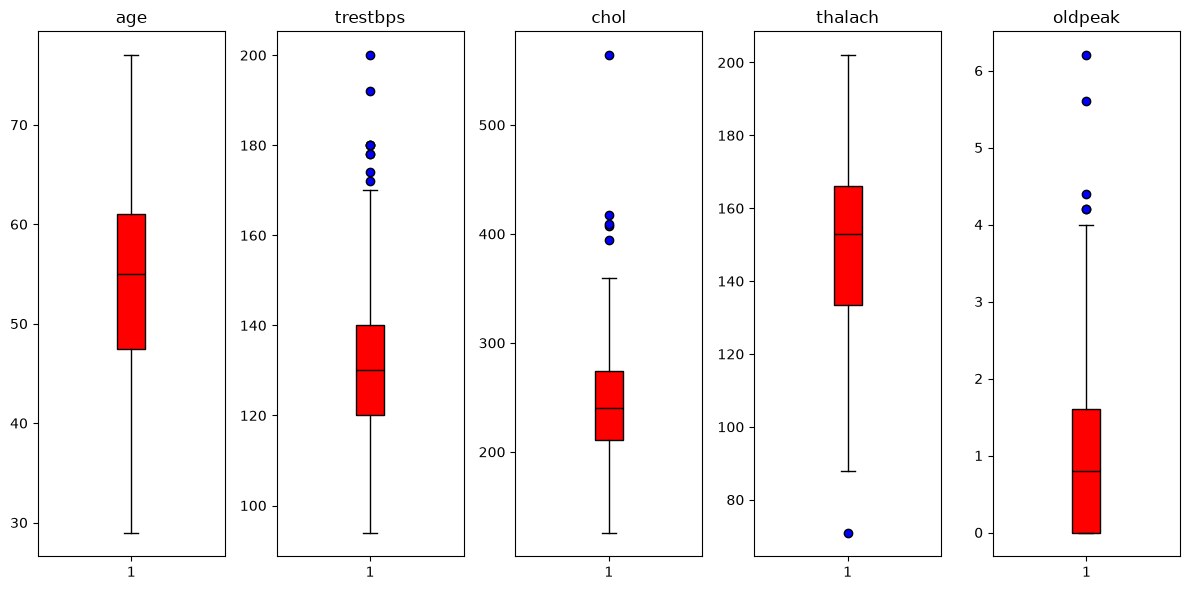

In [18]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if number_unique > 6:
        col.append(index)
fig , ax = plt.subplots(figsize=(12,6),ncols=len(col))
for i ,column in enumerate(col):
    ax[i].boxplot(df[column],patch_artist=True,boxprops={"facecolor":"red"},medianprops={"color":"black"},flierprops={"markerfacecolor":"blue"})
    ax[i].set_title(column)
plt.tight_layout()


### Analysis of Question 16

طبق نمودار های بالا فقط سن داده پرت ندارد


---

### سوال 17

برای تمام ویژگی‌های عددی KDE Plot رسم کنید.

تحلیل:

- نرمال بودن یا نبودن توزیع

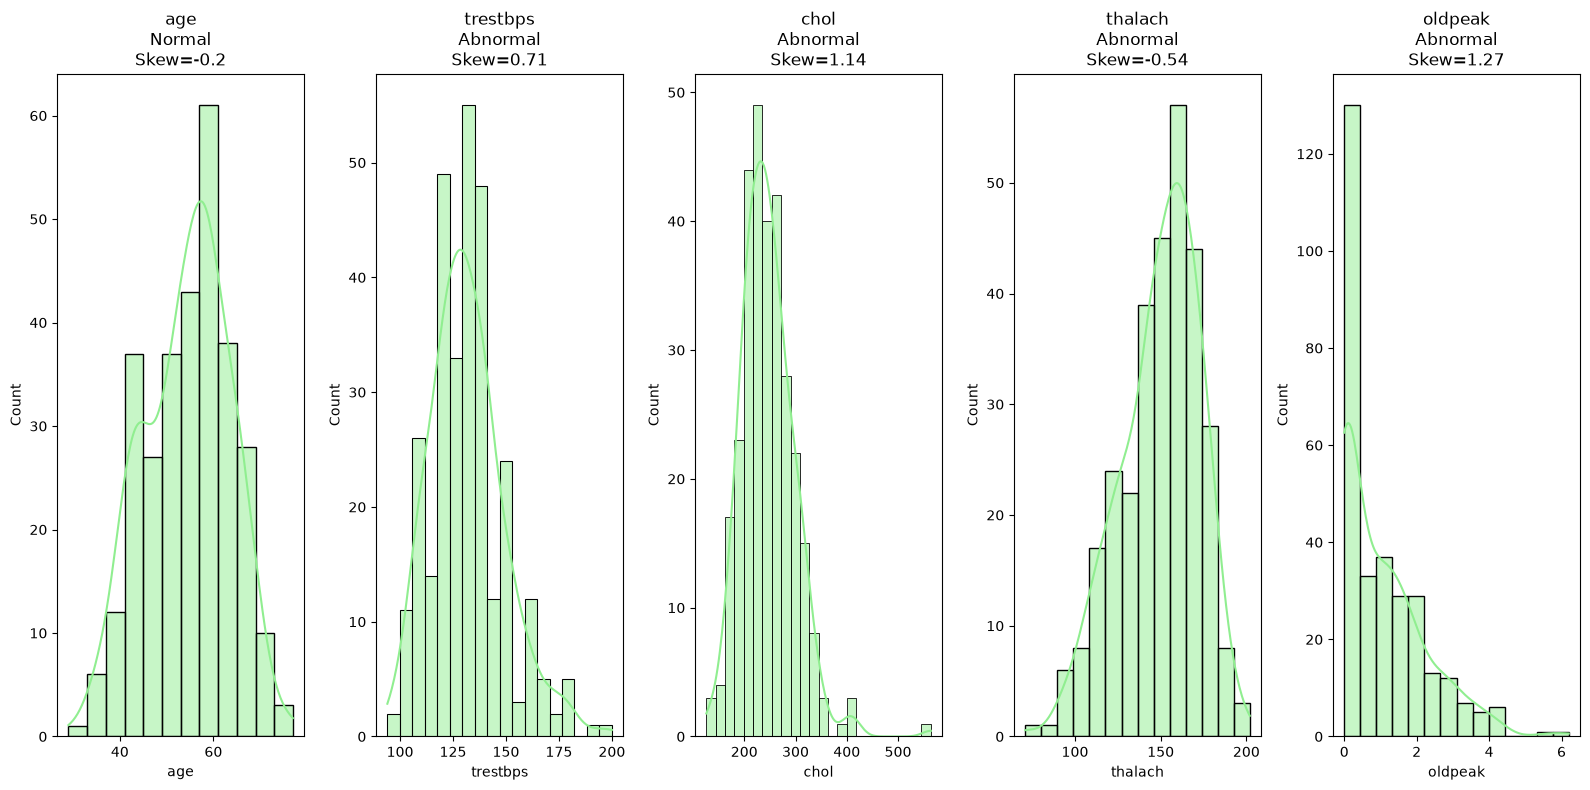

In [19]:
fig, ax = plt.subplots(figsize=(16,8), ncols=5)
for index, column in enumerate(col):
    skew = df[column].skew().round(2)
    sns.histplot(df[column], kde=True, ax=ax[index], color="lightgreen")
    ax[index].set_title(f"{column}\n{'Normal' if -0.5 < skew < 0.5 else 'Abnormal'}\nSkew={skew}")
plt.tight_layout()
plt.show()


### Analysis of Question 17

این پلات ها نشان می‌دهند که بیشتر ویژگی‌های عددی توزیع نرمال کامل ندارند
در ویژگی‌هایی مانند کلسترول و افت موج عدم تقارن و کشیدگی مشاهده می‌شود
ویژگی سن نسبتاً به توزیع نرمال نزدیک است
 برای بسیاری از ویژگی‌ها فرض نرمال بودن داده‌ها برقرار نیست و در تحلیل‌های آماری باید این موضوع در نظر گرفته شود


---

# بخش پنجم: تحلیل ویژگی‌های دسته‌ای

### سوال 18

برای تمام ویژگی‌های دسته‌ای:

فراوانی هر دسته را محاسبه کنید.

In [58]:
col = []
dict_faravani={}
for index in df.columns:
    number_unique = df[index].nunique()
    if 6 > number_unique > 2:
        col.append(index)
for index , column in enumerate(col):
    v_count = df[column].value_counts()
    print(v_count)
    


cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64
restecg
1    152
0    147
2      4
Name: count, dtype: int64
slope
2    142
1    140
0     21
Name: count, dtype: int64
ca
0    175
1     65
2     38
3     20
4      5
Name: count, dtype: int64
thal
2    166
3    117
1     18
0      2
Name: count, dtype: int64


### Analysis of Question 18

### cp

0    143

2     87

1     50

3     23


### restecg

1    152

0    147

2      4

### slope

2    142

1    140

0     21

### ca

0    175

1     65

2     38

3     20

4      5

### thal

2    166

3    117

1     18

0      2



---

### سوال 19

برای تمام ویژگی‌های دسته‌ای Countplot رسم کنید.

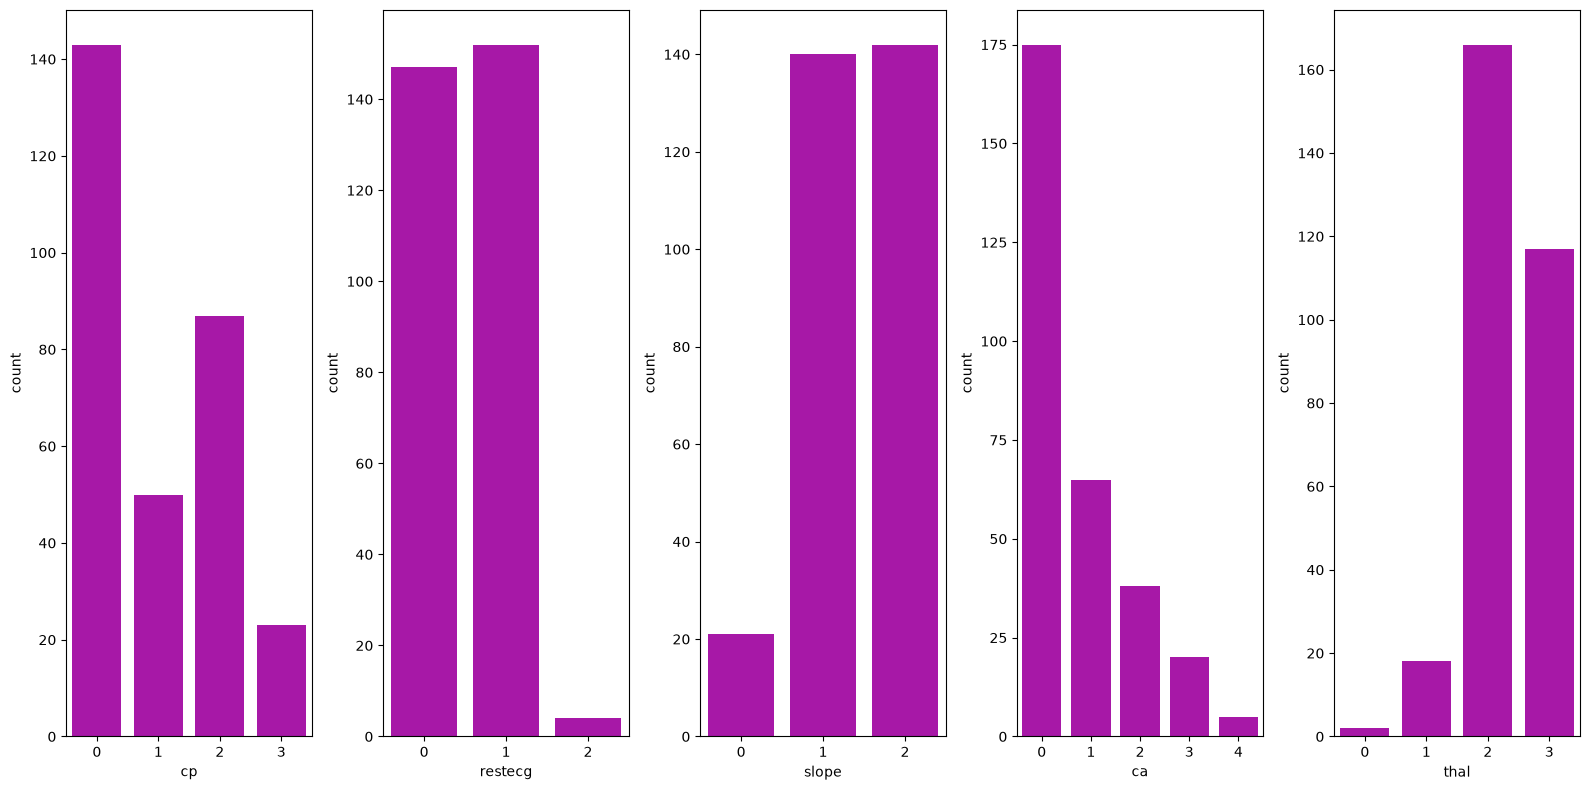

In [21]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if 6 > number_unique > 2:
        col.append(index)
fig , ax = plt.subplots(figsize=(16,8),ncols=5)
for index , column in enumerate(col):
    sns.countplot(data= df , x=column,ax=ax[index],color="m")
plt.tight_layout()
plt.show()


---

### سوال 20

بررسی کنید آیا توزیع جنسیت (sex) متعادل است یا خیر؟

In [60]:
c = df["sex"].value_counts()
balance = c.min() / c.max()
if balance > 0.8:
    print("balance")
else:
    print("is not balance")



is not balance


### Analysis of Question 20

طبق نمودار بالا جنسیت متعادل نیست


---

# بخش ششم: ارتباط ویژگی‌ها با هدف

### سوال 21

برای تمام ویژگی‌های عددی:

توزیع آنها را بر اساس target مقایسه کنید.

ابزار:

- boxplot
- violinplot

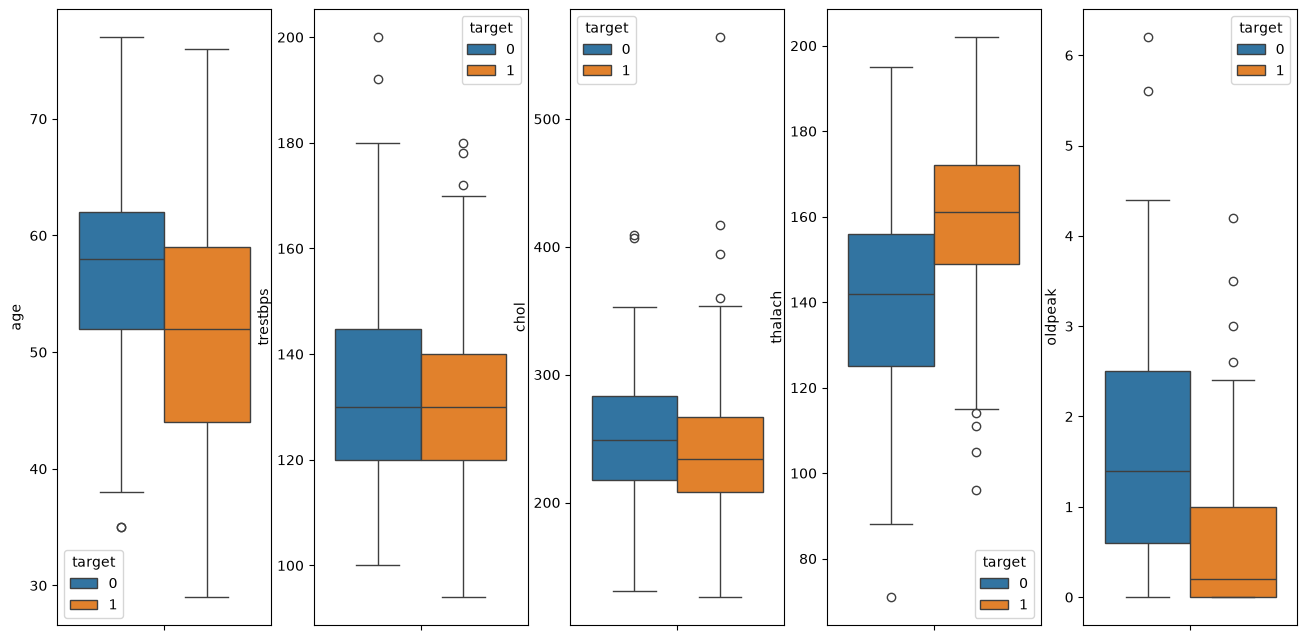

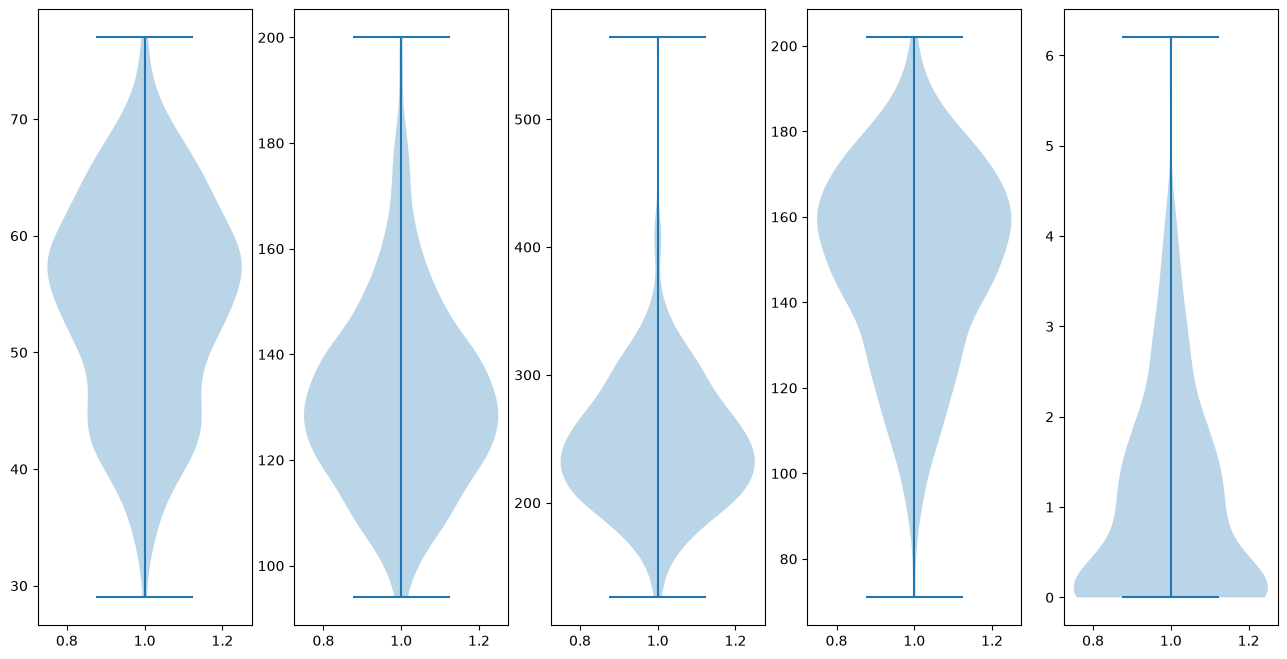

In [23]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if number_unique >  6:
        col.append(index)
fig,ax = plt.subplots(figsize=(16,8),ncols=5)
for i , column in enumerate(col):
    sns.boxplot(data = df,y = column,patch_artist=True,hue = df["target"],ax=ax[i])
plt.show()

fig_1,ax_1 = plt.subplots(figsize=(16,8),ncols=5)
for i , column in enumerate(col):
    ax_1[i].violinplot(df[column])
plt.show()




### Analysis of question 21

مقایسه توزیع ویژگی‌های عددی بر اساس تارگت نشان می‌دهد که بعضی متغیرها قدرت تفکیک خوبی بین افراد بیمار و سالم دارند
 برخی ویژگی‌ها ارتباط قوی‌تری با بیماری قلبی دارند و می‌توانند در مدل‌سازی مورد استفاده قرار گیرند


---

### سوال 22

برای ویژگی age بررسی کنید:

آیا افراد مسن‌تر بیشتر در کلاس بیماری قرار گرفته‌اند؟

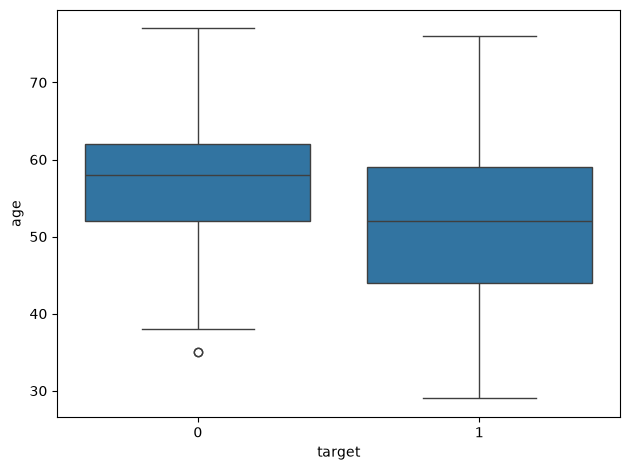

In [24]:
ax = sns.boxplot(df,y="age",x="target")
plt.tight_layout()
plt.show()



### Analysis of Question 22

 طبق نمودار بالا لزوما افراد مسن بیمار نیستن


---

### سوال 23

برای ویژگی chol بررسی کنید:

آیا بیماران دارای کلسترول بالاتر بیشتر بیمار هستند؟

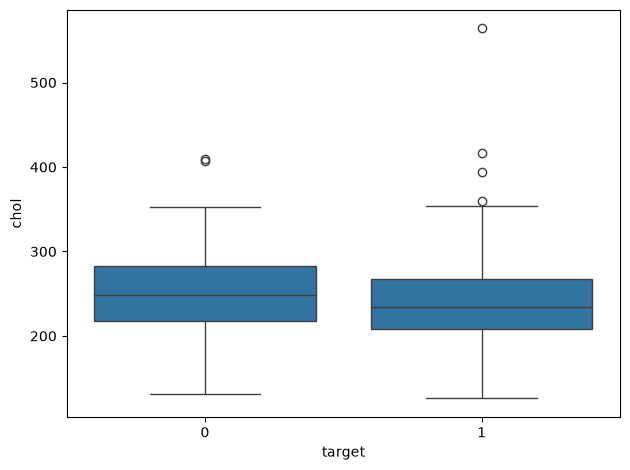

In [25]:
sns.boxplot(df,y="chol",x="target")
plt.tight_layout()
plt.show()

### Analysis of Question 23

 طبق نمودار بالا لزوما افراد دارای کلسترول بالاتر بیمار نیستن


---

### سوال 24

برای ویژگی thalach بررسی کنید:

حداکثر ضربان قلب در افراد بیمار و سالم چه تفاوتی دارد؟

/tmp/ipykernel_6406/306260933.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='thalach', palette='Set2')


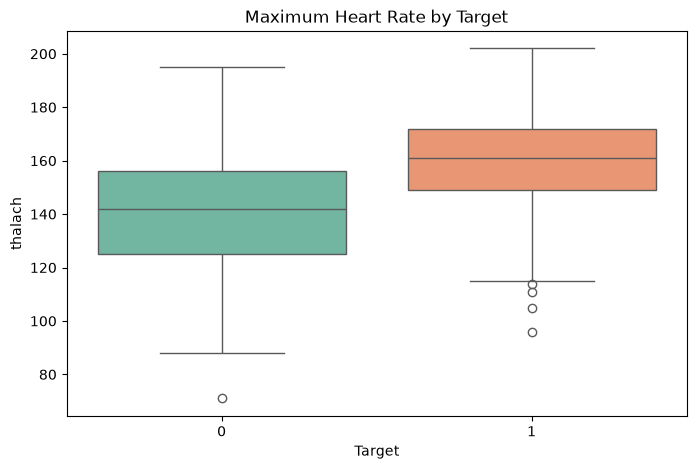

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,138.0,139.101449,22.598782,71.0,125.0,142.0,156.0,195.0
1,165.0,158.466667,19.174276,96.0,149.0,161.0,172.0,202.0


In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='target', y='thalach', palette='Set2')
plt.title('Maximum Heart Rate by Target')
plt.xlabel('Target')
plt.ylabel('thalach')
plt.show()
df.groupby('target')['thalach'].describe()

### Analysis of Question 24

 توزیع حداکثر ضربان قلب در افراد بیمار و سالم متفاوت است. میانگین حداکثر ضربان قلب در افراد مبتلا بیشتر از افراد سالم است و این موضوع نشان می‌دهد که این ویژگی می‌تواند در تشخیص بیماری نقش مهمی داشته باشد. همچنین نمودار باکس پلات اختلاف بین دو گروه را به خوبی نمایش می‌دهد


---

### سوال 25

برای ویژگی oldpeak بررسی کنید:

رابطه آن با بیماری چیست؟

/tmp/ipykernel_6406/4219201680.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='oldpeak', palette='Set1')


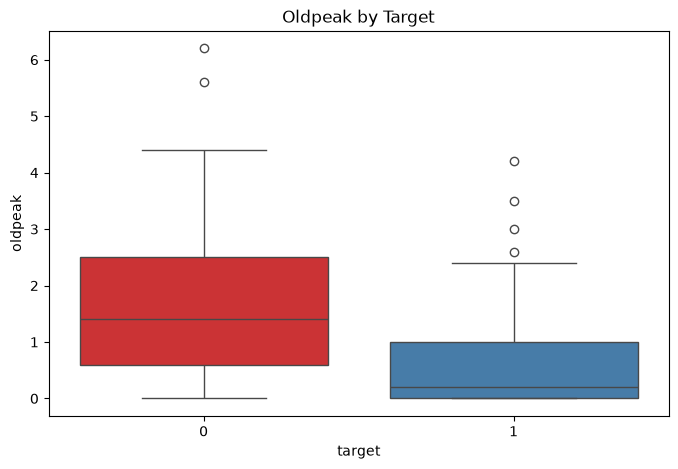

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,138.0,1.585507,1.300340,0.0,0.6,1.4,2.5,6.2
1,165.0,0.583030,0.780683,0.0,0.0,0.2,1.0,4.2


In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='target', y='oldpeak', palette='Set1')
plt.title('Oldpeak by Target')
plt.show()
df.groupby('target')['oldpeak'].describe()

### Analysis of Question 25

توزیع این ویژگی در دو گروه تفاوت محسوسی دارد. همچنین همبستگی نسبتاً بالای افت موج با تارگت نشان می‌دهد که این متغیر اطلاعات خوبی برای پیش‌بینی بیماری قلبی در اختیار مدل قرار می‌ دهد.بین میانگین و میانه در دو گروه نیز اختلاف وحود دارد



---

### سوال 26

برای تمام ویژگی‌های دسته‌ای:

Cross Tab با target ایجاد کنید.

ابزار:

- pd.crosstab()

In [28]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in cat_cols:
    print(f"\n{'--'*50}")
    print(col)
    print(pd.crosstab(df[col], df['target']))


----------------------------------------------------------------------------------------------------
sex
target    0   1
sex            
0        24  72
1       114  93

----------------------------------------------------------------------------------------------------
cp
target    0   1
cp             
0       104  39
1         9  41
2        18  69
3         7  16

----------------------------------------------------------------------------------------------------
fbs
target    0    1
fbs             
0       116  142
1        22   23

----------------------------------------------------------------------------------------------------
restecg
target    0   1
restecg        
0        79  68
1        56  96
2         3   1

----------------------------------------------------------------------------------------------------
exang
target   0    1
exang          
0       62  142
1       76   23

--------------------------------------------------------------------------------------------

### Analysis of Question 26

برخی دسته‌ها سهم بسیار بیشتری از بیماران را در خود جای داده‌اند. این موضوع بیانگر وجود رابطه میان برخی ویژگی‌های دسته‌ای و بیماری قلبی است. بنابراین استفاده از این ویژگی‌ها در مدل‌های طبقه‌بندی می‌تواند به افزایش دقت مدل کمک کند.


---

### سوال 27

برای ویژگی sex:

احتمال بیماری در مردان و زنان را مقایسه کنید.

sex
0    75.000000
1    44.927536
Name: target, dtype: float64


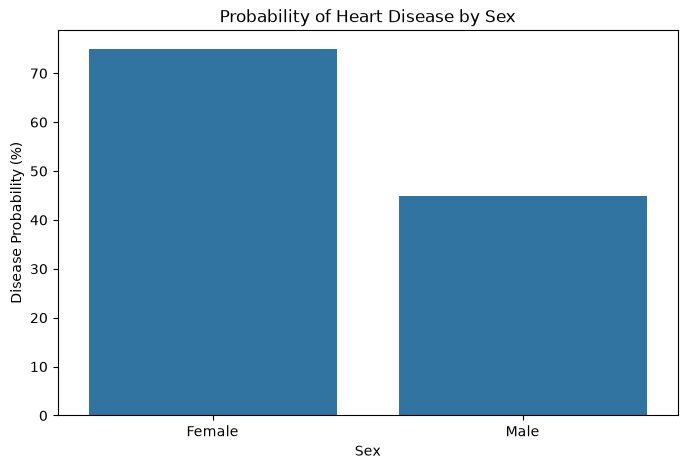

In [29]:
sex_prob = df.groupby('sex')['target'].mean() * 100
print(sex_prob)
plt.figure(figsize=(8,5))
sns.barplot(x=sex_prob.index, y=sex_prob.values)
plt.xticks([0,1], ['Female','Male'])
plt.ylabel('Disease Probability (%)')
plt.xlabel('Sex')
plt.title('Probability of Heart Disease by Sex')
plt.show()

### Analysis of Question 27

 از آنجا که تارگت یک متغیر باینری است میانگین آن مستقیماً نشان‌دهنده درصد افراد مبتلا در هر گروه است. مقایسه نتایج نشان می‌دهد که احتمال بیماری در دو جنس یکسان نیست و جنسیت تا حدی با وضعیت بیماری قلبی ارتباط دارد. با این حال اختلاف مشاهده‌شده به اندازه برخی ویژگی‌های مهم‌تر مانند نوع درد قفسه سینه افت موج و آنژین ناشی از ورزش قوی نیست بنابراین جنسیت به تنهایی برای پیش‌بینی بیماری کافی نخواهد بود و بهتر است در کنار سایر متغیرهای پزشکی مورد استفاده قرار گیرد.



---

### سوال 28

برای ویژگی cp (نوع درد قفسه سینه):

کدام دسته بیشترین ارتباط را با بیماری دارد؟

cp
0    27.272727
1    82.000000
2    79.310345
3    69.565217
Name: target, dtype: float64


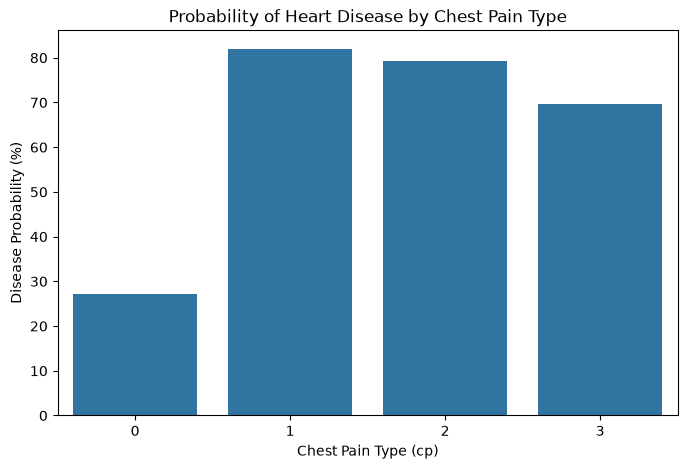

In [30]:
cp_prob = df.groupby('cp')['target'].mean() * 100
print(cp_prob)
plt.figure(figsize=(8,5))
sns.barplot(x=cp_prob.index, y=cp_prob.values)
plt.xlabel('Chest Pain Type (cp)')
plt.ylabel('Disease Probability (%)')
plt.title('Probability of Heart Disease by Chest Pain Type')
plt.show()

### Analysis of Question 28

   احتمال بیماری در دسته‌های مختلف نوع درد قفسه سینه تفاوت قابل توجهی دارد و برخی انواع درد قفسه سینه با احتمال بیشتری از بیماری قلبی همراه هستند. این اختلاف نشان می‌دهد که نوع درد قفسه سینه یکی از مهم‌ترین ویژگی‌های موجود در دیتاست است و قدرت تفکیک بالایی بین افراد سالم و بیمار دارد



---

### سوال 29

برای ویژگی exang:

آیا ورزش‌محور بودن درد با بیماری ارتباط دارد؟

exang
0    69.607843
1    23.232323
Name: target, dtype: float64


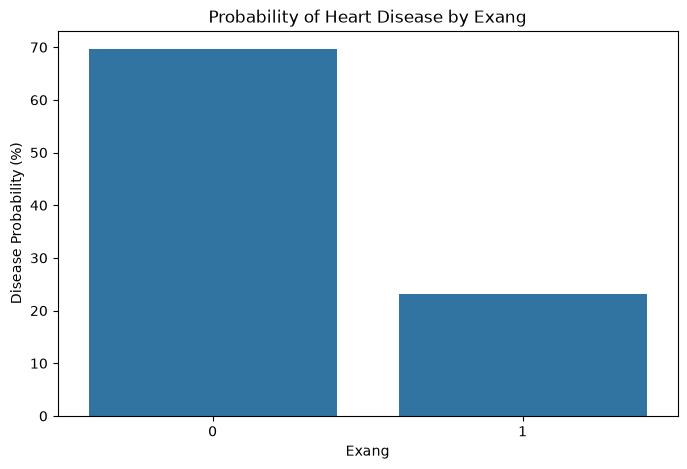

In [31]:
exang_prob = df.groupby('exang')['target'].mean() * 100
print(exang_prob)

plt.figure(figsize=(8,5))
sns.barplot(x=exang_prob.index, y=exang_prob.values)
plt.xlabel('Exang')
plt.ylabel('Disease Probability (%)')
plt.title('Probability of Heart Disease by Exang')
plt.show()

### Analysis of Question 29

توزیع افراد بیمار و سالم در دو مقدار این ویژگی متفاوت است. همچنین این ویژگی یکی از بالاترین ضرایب همبستگی را با متغیر تارگت دارد



---

# بخش هفتم: تحلیل روابط بین ویژگی‌ها

### سوال 30

ماتریس همبستگی را محاسبه کنید.

ابزار:

- corr()

In [32]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


### Analysis of Question 30

جدول ارتباط میان متغیرها نشان می‌ دهد که همه متغیرها تأثیر یکسانی بر یکدیگر ندارند. برخی از متغیرها دارای ارتباط قوی و برخی دارای ارتباط ضعیف هستند. این جدول به ما کمک می‌کند متغیرهایی را که رفتار مشابهی دارند شناسایی کنیم. همچنین می‌توان متغیرهایی را که بیشترین ارتباط را با وضعیت بیماری دارند تشخیص داد و در مراحل بعدی از آن‌ها استفاده کنیم



---

### سوال 31

Heatmap همبستگی رسم کنید.

ابزار:

- sns.heatmap()

[Text(0, 0, 'age'),
 Text(0, 1, 'sex'),
 Text(0, 2, 'cp'),
 Text(0, 3, 'trestbps'),
 Text(0, 4, 'chol'),
 Text(0, 5, 'fbs'),
 Text(0, 6, 'restecg'),
 Text(0, 7, 'thalach'),
 Text(0, 8, 'exang'),
 Text(0, 9, 'oldpeak'),
 Text(0, 10, 'slope'),
 Text(0, 11, 'ca'),
 Text(0, 12, 'thal'),
 Text(0, 13, 'target')]

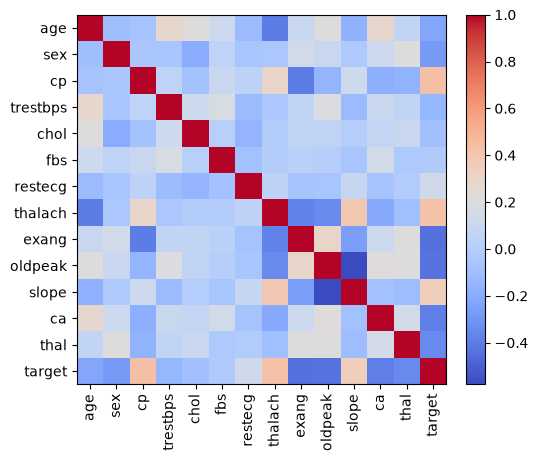

In [33]:
corr_matrix =df.corr()
fig ,ax = plt.subplots()
img = ax.imshow(corr_matrix,cmap="coolwarm")
cbar = fig.colorbar(img,ax=ax,fraction = 0.05 , pad = 0.04)
ax.set_xticks(np.arange(len(df.columns)))
ax.set_yticks(np.arange(len(df.columns)))
ax.set_xticklabels(df.columns,rotation = 90)
ax.set_yticklabels(df.columns)

### Analysis of Question 31

نقشه رنگی ارتباط میان متغیرها امکان مقایسه سریع شدت ارتباط‌ها را فراهم می‌کند. خانه‌هایی با رنگ پررنگ‌تر نشان‌دهنده ارتباط قوی‌تر هستند. مشاهده می‌شود که تنها تعداد محدودی از متغیرها دارای ارتباط نسبتاً زیاد با یکدیگر هستند و بیشتر ارتباط‌ها در حد ضعیف تا متوسط قرار دارند. این موضوع نشان می‌دهد که بیشتر متغیرها اطلاعات متفاوتی را در اختیار مدل قرار می‌دهند



---

### سوال 32

بیشترین همبستگی مثبت با target مربوط به کدام ویژگی است؟

In [34]:
corr = df.corr()
corr["target"].sort_values(ascending=False)

target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64

### Analysis of Question 32

بیشترین ارتباط مثبت با متغیر بیماری مربوط به نوع درد قفسه سینه است. این نتیجه نشان می‌دهد که نوع درد قفسه سینه می‌تواند نقش مهمی در تشخیص وضعیت بیمار داشته باشد. 


---

### سوال 33

بیشترین همبستگی منفی با target مربوط به کدام ویژگی است؟

### Analysis of Question 33

مربوط به exang

In [35]:
corr = df.corr()
corr["target"].sort_values()

exang      -0.436757
oldpeak    -0.430696
ca         -0.391724
thal       -0.344029
sex        -0.280937
age        -0.225439
trestbps   -0.144931
chol       -0.085239
fbs        -0.028046
restecg     0.137230
slope       0.345877
thalach     0.421741
cp          0.433798
target      1.000000
Name: target, dtype: float64

### Analysis of Question 33

بیشترین ارتباط منفی با متغیر بیماری مربوط به درد قفسه سینه ناشی از فعالیت بدنی است. منفی بودن مقدار ارتباط نشان می‌دهد که با تغییر این متغیر احتمال قرار گرفتن در یکی از گروه‌های بیماری در جهت مخالف تغییر می‌کند


---

### سوال 34

سه جفت ویژگی با بالاترین همبستگی را پیدا کنید.

In [75]:
corr_matrix = df.drop(columns='target').corr().abs()
mask = corr_matrix == 1
corr_matrix = corr_matrix[~mask]
for i in range(len(corr_matrix)):
    for j in range(i+1):
        corr_matrix.iloc[i,j] = np.nan
corr_matrix.unstack().sort_values(ascending=False)


slope    oldpeak    0.577537
thalach  age        0.398522
exang    cp         0.394280
slope    thalach    0.386784
exang    thalach    0.378812
                      ...   
slope    ca              NaN
         thal            NaN
ca       ca              NaN
         thal            NaN
thal     thal            NaN
Length: 169, dtype: float64

### Analysis of Question 34

slope oldpeak

talach age

exang cp


---

### سوال 35

Scatter Plot بین موارد زیر رسم کنید:

- age و chol
- age و thalach
- chol و trestbps

و رنگ را بر اساس target تعیین کنید.

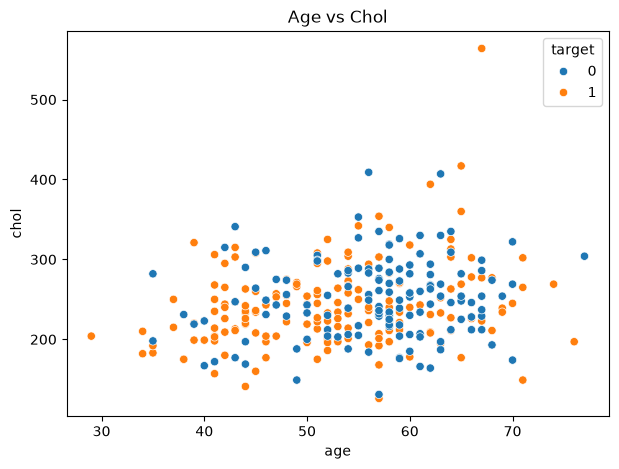

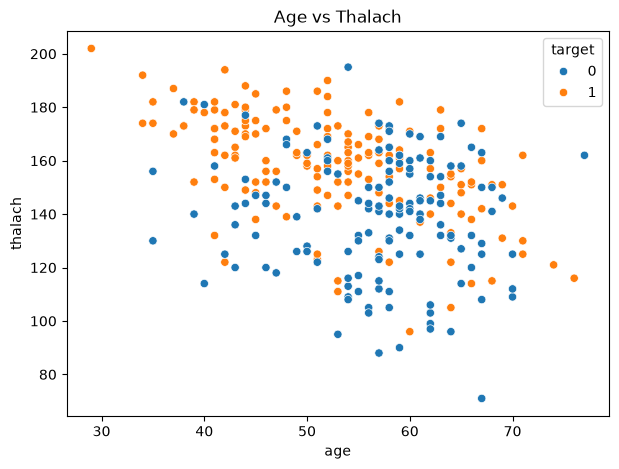

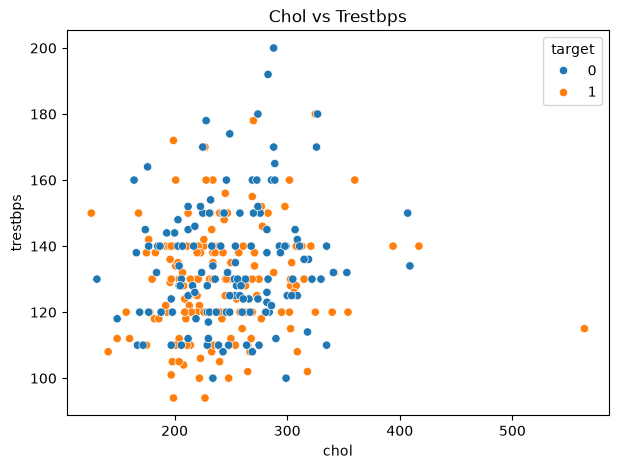

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=df, x="age", y="chol", hue="target", ax=ax)
ax.set_title("Age vs Chol")
plt.show()

fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=df, x="age", y="thalach", hue="target", ax=ax)
ax.set_title("Age vs Thalach")
plt.show()

fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=df, x="chol", y="trestbps", hue="target", ax=ax)
ax.set_title("Chol vs Trestbps")
plt.show()

### Analysis of Question 35


نمودارهای پراکندگی نشان می‌دهند که رابطه میان متغیرها همیشه خطی و ساده نیست. در برخی نمودارها نقاط مربوط به افراد سالم و بیماران تا حدی از یکدیگر جدا شده‌اند، اما در برخی دیگر هم‌پوشانی زیادی وجود دارد. این موضوع نشان می‌دهد که استفاده از یک متغیر به تنهایی برای تشخیص بیماری کافی نیست. ترکیب چند متغیر در کنار یکدیگر می‌تواند قدرت تشخیص را افزایش دهد.


---

### سوال 36

Pairplot برای مهم‌ترین ویژگی‌ها رسم کنید.

ابزار:

- sns.pairplot()

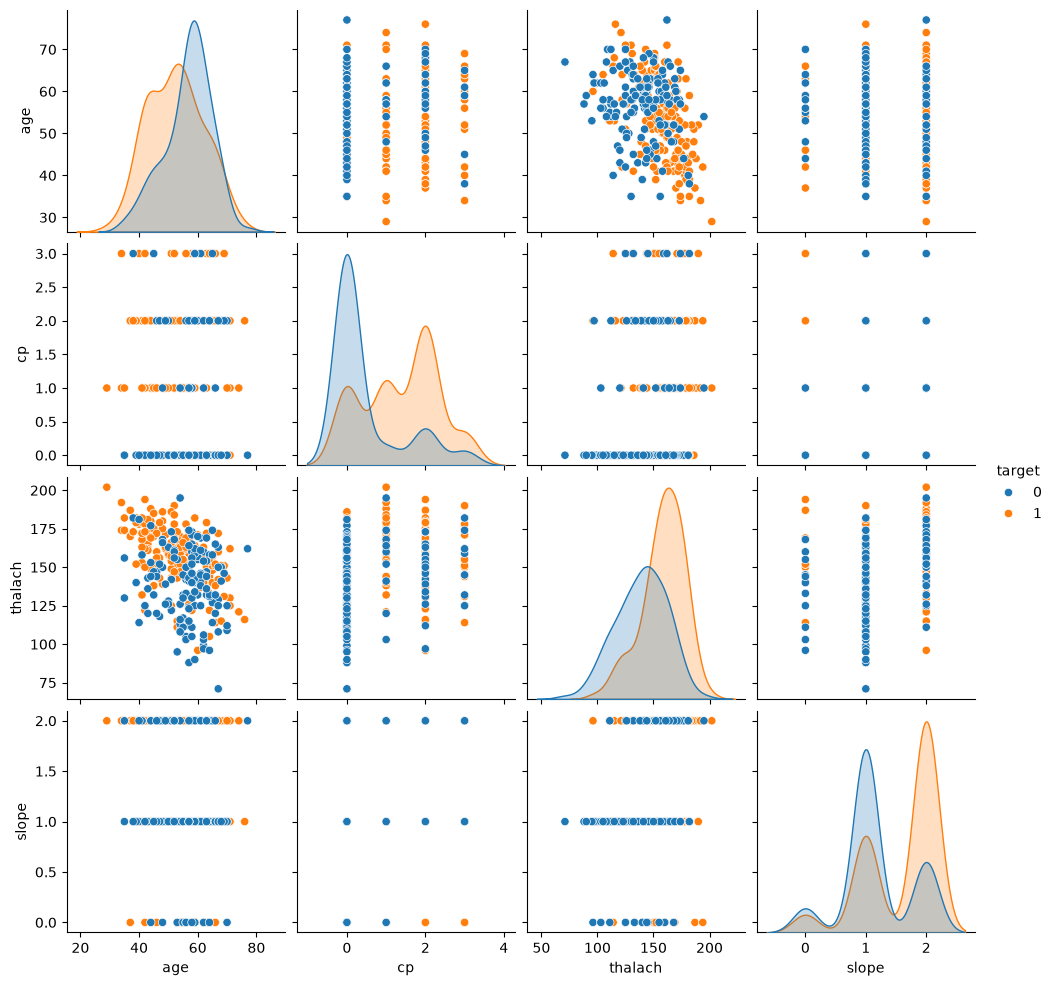

In [ ]:
important_features = ["age", "cp", "thalach", "slope","target"]
sns.pairplot(df[important_features], hue="target")
plt.show()

### Analysis of Question 36

نمودارهای جفتی امکان بررسی همزمان روابط میان چند متغیر مهم را فراهم می‌کنند. با مشاهده این نمودارها می‌توان میزان جدایی افراد سالم و بیمار را در ترکیب‌های مختلف متغیرها بررسی کرد. در برخی از ترکیب‌ها مرز بین دو گروه واضح‌تر دیده می‌شود که نشان‌دهنده ارزش بالای آن متغیرها در تشخیص بیماری است. این نمودارها برای انتخاب متغیرهای مناسب جهت ساخت مدل بسیار مفید هستند.


---

# بخش هشتم: تحلیل چندمتغیره

### سوال 37

میانگین تمام ویژگی‌های عددی را برای دو کلاس target مقایسه کنید.

In [ ]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if number_unique > 6:
        col.append(index)
df.groupby("target")[col].mean().unstack()

          target
age       0          56.601449
          1          52.496970
trestbps  0         134.398551
          1         129.303030
chol      0         251.086957
          1         242.230303
thalach   0         139.101449
          1         158.466667
oldpeak   0           1.585507
          1           0.583030
dtype: float64

### Analysis of Question 37

مقایسه میانگین متغیرهای عددی در دو گروه نشان می‌دهد که بین افراد سالم و بیمار تفاوت‌های مشخصی وجود دارد. برخی متغیرها مانند بیشترین تعداد ضربان قلب و میزان افت قطعه قلبی اختلاف قابل توجهی بین دو گروه دارند. این اختلاف‌ها نشان می‌دهد که این متغیرها می‌توانند در شناسایی وضعیت افراد مؤثر باشند.


---

### سوال 38

گروه‌بندی بر اساس sex و target انجام دهید و میانگین ویژگی‌ها را مقایسه کنید.

ابزار:

- groupby()

In [ ]:
df.groupby(by=["target","sex"]).mean().unstack()

age                   cp              trestbps              \
sex             0          1         0         1           0           1   
target                                                                     
0       59.041667  56.087719  0.166667  0.543860  146.125000  131.929825   
1       54.555556  50.903226  1.333333  1.408602  128.736111  129.741935   

              chol                   fbs            ...     exang           \
sex              0           1         0         1  ...         0        1   
target                                              ...                      
0       274.958333  246.061404  0.250000  0.140351  ...  0.583333  0.54386   
1       256.750000  230.989247  0.083333  0.182796  ...  0.111111  0.16129   

         oldpeak               slope                  ca           thal  \
sex            0         1         0         1         0         1    0   
target                                                                    
0       1.841667  1.531579  0.958333  1.210526  1.291667  1.140351  2.5   
1       0.554167  0.605376  1.583333  1.602151  0.305556  0.408602  2.0   

                  
sex            1  
target            
0       2.552632  
1       2.215054  

[2 rows x 24 columns]

### Analysis of Question 38

با گروه‌بندی همزمان بر اساس جنسیت و وضعیت بیماری مشخص می‌شود که الگوهای سلامت در مردان و زنان کاملاً یکسان نیست. میانگین برخی متغیرها در گروه‌های مختلف تفاوت دارد و این موضوع نشان‌دهنده اثر جنسیت بر برخی شاخص‌های پزشکی است. با این حال اختلاف مشاهده‌شده در همه متغیرها یکسان نیست. بنابراین جنسیت می‌تواند یکی از عوامل مؤثر باشد اما به تنهایی برای تشخیص بیماری کافی نیست.


---

### سوال 39

گروه‌بندی بر اساس cp و target انجام دهید.

In [ ]:
df.groupby(by=["target","cp"]).size().unstack()

cp,0,1,2,3
target,,,,
0,104,9,18,7
1,39,41,69,16


### Analysis of Question 39

گروه‌بندی بر اساس نوع درد قفسه سینه و وضعیت بیماری نشان می‌دهد که میانگین بسیاری از متغیرها در دسته‌های مختلف تفاوت دارد. برخی انواع درد قفسه سینه بیشتر با ویژگی‌های مرتبط با بیماری همراه هستند. این موضوع نشان می‌دهد که نوع درد قفسه سینه یکی از مهم‌ترین شاخص‌های موجود در مجموعه داده است. نتایج این تحلیل نیز اهمیت بالای این متغیر را در تشخیص بیماری تأیید می‌کند



---

### سوال 40

سه پروفایل مختلف از بیماران استخراج کنید:

مثال:

- بیمار پرریسک
- بیمار کم‌ریسک
- بیمار مرزی

(فقط بر اساس مشاهده داده‌ها)

In [ ]:
risk_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
print(df[risk_features].describe())

              age    trestbps        chol     thalach     oldpeak
count  303.000000  303.000000  303.000000  303.000000  303.000000
mean    54.366337  131.623762  246.264026  149.646865    1.039604
std      9.082101   17.538143   51.830751   22.905161    1.161075
min     29.000000   94.000000  126.000000   71.000000    0.000000
25%     47.500000  120.000000  211.000000  133.500000    0.000000
50%     55.000000  130.000000  240.000000  153.000000    0.800000
75%     61.000000  140.000000  274.500000  166.000000    1.600000
max     77.000000  200.000000  564.000000  202.000000    6.200000


### Analysis of Question 40

یمار کم‌خطر: سن پایین، فشار خون نرمال، کلسترول نرمال، افت موج پایین و عدم وجود آنژین ناشی از ورزش
بیمار متوسط: برخی شاخص‌ها در محدوده مرزی قرار دارند و چند عامل خطر مشاهده می‌شود
بیمار پرخطر: سن بالا، افت موج زیاد، وجود انژین ناشی از ورزش تعداد رگ‌های درگیر بیشتر و مقادیر غیرطبیعی تالاسمی



---

# گزارش نهایی (مهم‌ترین بخش پروژه)

در پایان دانشجو باید به این ۵ سوال مدیریتی پاسخ دهد:

1. مهم‌ترین ویژگی‌هایی که احتمالاً با بیماری قلبی ارتباط دارند کدام‌اند؟
2. کدام ویژگی‌ها برای مدل‌سازی آینده احتمالاً ارزش بیشتری دارند؟
3. چه مشکلاتی در داده مشاهده شد؟ (فقط شناسایی، نه رفع)
4. اگر مدیر بیمارستان فقط اجازه استفاده از ۵ ویژگی را بدهد، شما کدام ۵ ویژگی را پیشنهاد می‌کنید و چرا؟
5. آیا این دیتاست برای ورود به مرحله Data Preparation مناسب به نظر می‌رسد؟ چرا؟

---

### final outcome


در این مطالعه دیتاست مربوط به بیماری قلبی مورد بررسی قرار گرفت. هدف اصلی شناخت ویژگی‌ های داده از یک سو و تعیین عوامل موثر در بروز بیماری از سوی دیگر بود. 
از نظر کیفیت داده وضعیت نسبتا مطلوب بود: تنها یک رکورد تکراری شناسایی شد و مقدار گمشده‌ ای در میان داده‌ ها دیده نشد که نکته‌ ی مثبتی به شمار می‌ رود. توزیع افراد سالم و بیملر هم تقریبا متوازن بود — حدود ۵۴ درصد بیمار در برابر ۴۶ درصد سالم. این موضوع اهمیت دارد چون وقتی یکی از دو کلاس به‌ مراتب کم ‌تعداد باشد، نتیجه‌ی مدل‌سازی معمولا سوگیری پیدا می‌کند و دقت آن در عمل کمتر از چیزی است که در ابتدا به نظر می ‌رسد.
نگاهی به متغیرهای عددی نیز نکات قابل‌ توجهی را روشن کرد. سن، فشار خون، کلسترول و حداکثر ضربان قلب همگی پراکندگی بالایی داشتند، و توزیع‌شان در بسیاری موارد از حالت نرمال فاصله می‌گرفت؛ در برخی متغیرها چولگی مشخصی هم به چشم می‌خورد که نشان می‌ دهد توزیع داده‌ ها چندان یکدست نیست. با توجه به این ویژگی‌ ها، و به‌ طور کلی با در نظر گرفتن پراکندگی بالای این متغیر ها، به نظر می‌ رسد در گام‌های بعدی، استانداردسازی یا نرمال‌ سازی داده‌ ها می‌ تواند به ثبات و عملکرد بهتر مدل‌ های پیشبینی کمک کند.
وقتی ارتباط متغیر ها با وضعیت بیماری بررسی شد، چند عامل بیش از بقیه برجسته بودند: نوع درد قفسه سینه، وجود درد ناشی از فعالیت بدنی، میزان افت موج 
 تعداد رگ ‌های درگیر، و حداکثر ضربان قلب. تفاوت میان افراد سالم و بیمار در این متغیر ها به‌ قدری معنادار بود که می‌ توان آن‌ ها را از مهم‌ ترین ویژگی پیشبینی بیماری دانست.
نکته‌ ی جالب دیگری که در بررسی روابط بین ویژگی‌ ها به دست آمد رابطه‌ ی معکوس میان سن و حداکثر ضربان قلب بود هرچه سن بالاتر می‌ رفت این مقدار روند نزولی پیدا می‌ کرد. این الگو با شواهد پزشکی شناخته‌شده هم‌راستا است و از این جهت یافته‌ی تازه‌ای محسوب نمی‌شود، اما تأییدی بر صحت داده‌ها به شمار می‌رود.
در سمت متغیر های دسته‌ ای هم تفاوت‌ های قابل ‌توجهی دیده شد. به‌ خصوص نوع درد قفسه سینه و وجود درد ناشی از فعالیت بدنی، عواملی بودند که میزان بیماری را در گروه‌ های مختلف به‌ وضوح متفاوت می‌ کردند این یعنی احتمال بیماری در همه‌ی زیرگروه‌ ها یکسان نیست و همین موضوع دوباره اهمیت این دو متغیر را نشان می‌ دهد.
با کنار هم گذاشتن این الگو ها می‌ توان افراد را در سه دسته‌ ی کلی جای داد: کم‌خطر، با خطر متوسط، و پرخطر. در گروه پرخطر معمولا چند ویژگی به‌طور هم‌زمان از محدوده‌ ی طبیعی خارج می‌ شوند و همین هم‌ زمانی است که ریسک را بالا می‌برد. در حالی که افراد کم‌ خطر اغلب در اکثر ویژگی ها در بازه‌ ی طبیعی باقی می‌ مانند، هرچند استثنا هم در این میان دیده می‌ شود.
در نهایت آن‌ چه از مجموع این یافته‌ ها برمی ‌آید این است که نمی‌ توان وضعیت سلامت فردی را تنها بر اساس یک ویژگی قضاوت کرد. توجه هم‌زمان به مجموعه ‌ای از عوامل مرتبط، هم به طراحی مدل‌های پیشبینی دقیق‌تر کمک می‌ کند و هم می‌ تواند شناسایی زودهنگام افراد در معرض خطر را ممکن‌ تر بسازد.

# هدف آموزشی پنهان این تمرین

اگر دانشجو همه ۴۰ سوال را انجام دهد، عملاً با:

- Pandas Profiling ذهنی
- Univariate Analysis
- Bivariate Analysis
- Multivariate Analysis
- Distribution Analysis
- Correlation Analysis
- Business Understanding Validation

آشنا می‌شود و بدون اینکه حتی یک مدل بسازد، می‌تواند مانند یک Data Analyst حرفه‌ای درباره دیتاست صحبت کند. این دقیقاً خروجی مطلوب مرحله Data Understanding در CRISP-DM است.